In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [4]:
features = pd.read_csv("../data/features.csv", index_col=0)

X = features.drop(columns="target_vol")
y = features["target_vol"]

print(X.shape, y.shape)

(3964, 12) (3964,)


In [5]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3171, 12)
Test: (793, 12)


In [6]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost training complete!")

XGBoost training complete!


In [7]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.002646
RMSE : 0.004423
R²   : 0.0558


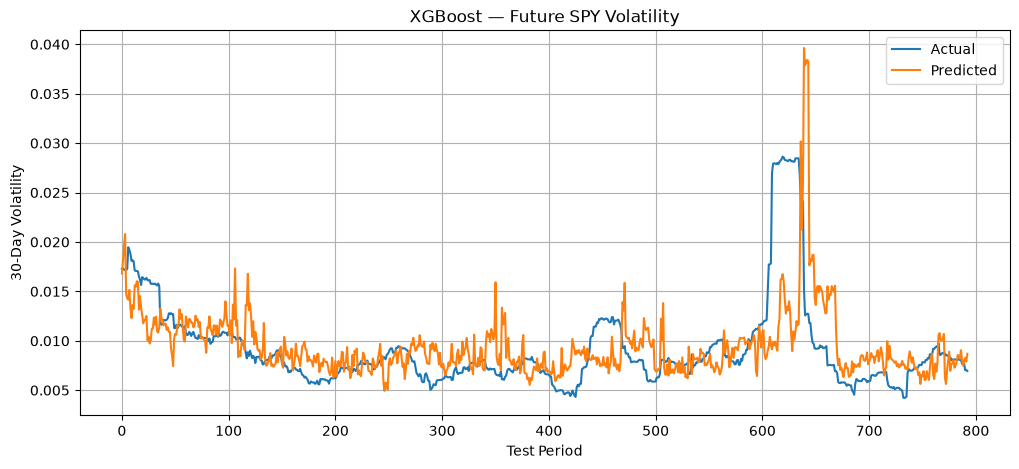

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("XGBoost — Future SPY Volatility")
plt.xlabel("Test Period")
plt.ylabel("30-Day Volatility")
plt.legend()
plt.grid(True)
plt.show()

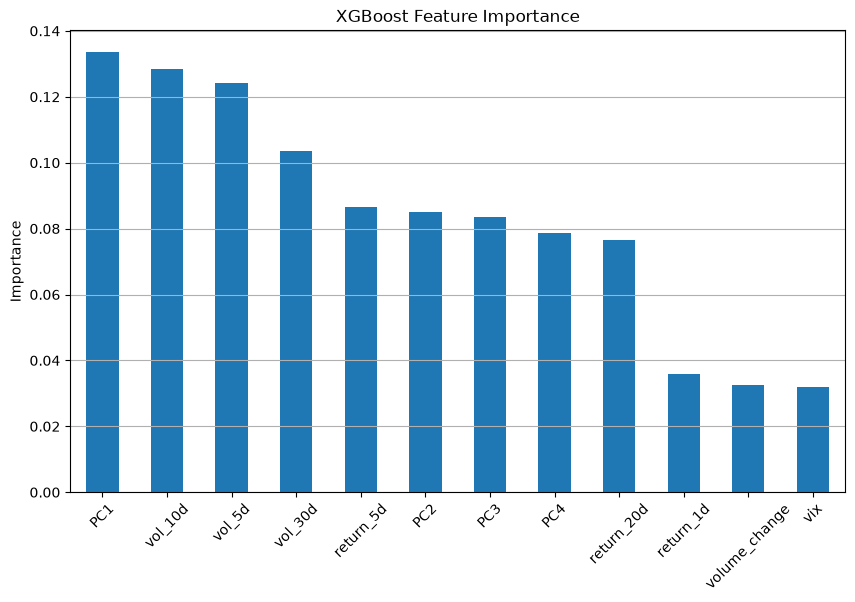

PC1              0.133518
vol_10d          0.128487
vol_5d           0.124149
vol_30d          0.103445
return_5d        0.086504
PC2              0.085087
PC3              0.083609
PC4              0.078663
return_20d       0.076488
return_1d        0.035750
volume_change    0.032397
vix              0.031903
dtype: float32


In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

print(importance)